<a href="https://colab.research.google.com/github/ankitverma969/Machine_Learning_Practice/blob/master/LangGraph/ConditionalGraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>Graph - IV</h1>

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [2]:
from IPython.core.compilerop import operator
# Schema
class AgentState(TypedDict):
  num1 : int
  operation : str
  num2 : int
  finalNum : int

In [3]:
# Process Vlaues and Update the state
def adder(state : AgentState) -> AgentState:
  state['finalNum'] = state['num1'] + state['num2']

  return state

def substractor(state : AgentState) -> AgentState:
  state['finalNum'] = state['num1'] - state['num2']

  return state

In [4]:
def decide_next_node(state:AgentState) -> AgentState:
  if state['operation'] == "+":
    return "addition_operation"

  elif state['operation'] == '-':
    return "substraction_operation"

In [5]:
graph = StateGraph(AgentState)

graph.add_node("add_node", adder)
graph.add_node("subtract_node", substractor)
graph.add_node("router", lambda state:state) # passthrough function

graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
      "addition_operation" : "add_node",
      "substraction_operation" : "subtract_node"
    }
)

graph.add_edge("add_node", END)
graph.add_edge("subtract_node", END)

app = graph.compile()

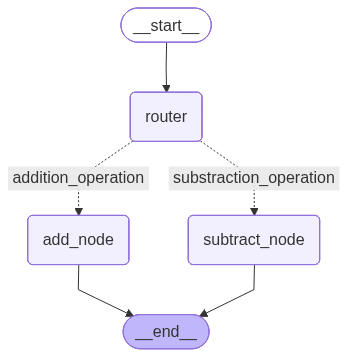

In [6]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [7]:
init_stage_1 = AgentState(num1 = 10, operation="-", num2 = 5)
print(app.invoke(init_stage_1))

{'num1': 10, 'operation': '-', 'num2': 5, 'finalNum': 5}


In [8]:
init_stage_1 = AgentState(num1 = 10, operation="+", num2 = 5)
print(app.invoke(init_stage_1))

{'num1': 10, 'operation': '+', 'num2': 5, 'finalNum': 15}
